# CycleGAN — Flip Rate & Confidence Change

Evaluates CycleGAN-generated counterfactuals using CheXNet as a fixed arbiter.

**Metrics computed separately for each translation direction:**
- **Flip Rate**: fraction of images where CheXNet changes its predicted class after translation
- **Confidence Change (Δ)**: P(pneumonia | translated) − P(pneumonia | original)

**No raw NIH images required** — originals are loaded from the preprocessed `test_dataset.pt`,
matched to synthetic images via the row order of `test_split.csv`.

## 0. Path configuration

In [13]:
import sys, kagglehub
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "utils"))

# Raw NIH images — downloaded via kagglehub (cached after first run)
DOWNLOAD_PATH = Path(kagglehub.dataset_download("nih-chest-xrays/data"))

SYNTHETIC_DIR    = PROJECT_ROOT / "synthetic" / "cycleGAN"
H2P_DIR          = SYNTHETIC_DIR / "healthy_to_pneumonia"
P2H_DIR          = SYNTHETIC_DIR / "pneumonia_to_healthy"
TEST_SPLIT_CSV   = PROJECT_ROOT / "data" / "splits" / "test_split.csv"
#TEST_DATASET_PT  = PROJECT_ROOT / "data" / "processed" / "test_dataset.pt"
CHEXNET_CKPT     = PROJECT_ROOT / "models" / "Classifier" / "chexnet.pth.tar"
RESULTS_DIR      = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print("DOWNLOAD_PATH :", DOWNLOAD_PATH)
print("H2P images    :", len(list(H2P_DIR.glob("*.png"))))
print("P2H images    :", len(list(P2H_DIR.glob("*.png"))))

DOWNLOAD_PATH : /Users/mabosco/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3
H2P images    : 60353
P2H images    : 322


## 1. Load CheXNet (fixed arbiter)

In [12]:
import torch
from models.Classifier.classifier import CheXNet
from device import get_device

DEVICE = get_device()
chexnet = CheXNet(CHEXNET_CKPT).to(DEVICE)
print(f"CheXNet loaded on {DEVICE} | eval={not chexnet.training} | trainable params=0")

CheXNet loaded on mps | eval=True | trainable params=0


## 2. Build filename → original image mapping

`test_split.csv` and `test_dataset.pt` were created in the same preprocessing run,
so row `i` in the CSV corresponds to index `i` in the dataset.
We verify this assumption by comparing label sequences before proceeding.

In [14]:
import pandas as pd

test_df = pd.read_csv(TEST_SPLIT_CSV).reset_index(drop=True)

print(f"CSV rows: {len(test_df)}")
print(f"Healthy  : {(test_df['Label'] == 0).sum()}")
print(f"Pneumonia: {(test_df['Label'] == 1).sum()}")

CSV rows: 9176
Healthy  : 8978
Pneumonia: 198


In [16]:
test_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Patient Age Normalized,Patient Gender Encoded,Label
0,00000218_000.png,Infiltration|Pneumonia,0,218,33,M,PA,2500,2048,0.171,0.171,0.352273,1,1
1,00000218_001.png,Pneumonia,1,218,33,M,PA,2048,2500,0.171,0.171,0.352273,1,1
2,00000310_001.png,Pneumonia,1,310,60,M,AP,2500,2048,0.171,0.171,0.659091,1,1
3,00000415_001.png,Fibrosis|Infiltration|Nodule|Pneumonia,1,415,68,F,AP,3056,2544,0.139,0.139,0.750000,0,1
4,00000499_008.png,Pneumonia,8,499,34,F,PA,2052,2271,0.143,0.143,0.363636,0,1


In [21]:
len(list(P2H_DIR.glob("*.png")))

322

In [20]:
test_df.Label.value_counts()

Label
0    8978
1     198
Name: count, dtype: int64

## 3. Separate test images by class and match with synthetic files

In [15]:
h2p_files = {p.name: p for p in H2P_DIR.glob("*.png")}
p2h_files = {p.name: p for p in P2H_DIR.glob("*.png")}

healthy_names   = set(test_df.loc[test_df["Label"] == 0, "Image Index"])
pneumonia_names = set(test_df.loc[test_df["Label"] == 1, "Image Index"])

h2p_pairs = [(name, h2p_files[name]) for name in healthy_names if name in h2p_files]
p2h_pairs = [(name, p2h_files[name]) for name in pneumonia_names if name in p2h_files]

print(f"H→P usable pairs: {len(h2p_pairs)}")
print(f"P→H usable pairs: {len(p2h_pairs)}")

H→P usable pairs: 8978
P→H usable pairs: 43


## 4. Helper functions

In [29]:
from PIL import Image
from torchvision import transforms
from typing import Optional

resize_224 = transforms.Resize((224, 224), antialias=True)
to_tensor  = transforms.ToTensor()


def _find_raw_image(nih_filename: str) -> Optional[Path]:
    """Search for an original NIH image across images_001 … images_012 subdirs."""
    for i in range(1, 13):
        candidate = DOWNLOAD_PATH / f"images_{i:03d}" / "images" / nih_filename
        if candidate.exists():
            return candidate
    return None


def original_tensor(nih_filename: str) -> torch.Tensor:
    raw_path = _find_raw_image(nih_filename)
    if raw_path is None:
        raise FileNotFoundError(f"{nih_filename} not found in {DOWNLOAD_PATH}")
    return resize_224(to_tensor(Image.open(raw_path).convert("L"))).unsqueeze(0)


def synthetic_tensor(path: Path) -> torch.Tensor:
    """Load a CycleGAN-generated image as a (1, 1, 224, 224) tensor."""
    img = Image.open(path).convert("L")
    return resize_224(to_tensor(img)).unsqueeze(0)


@torch.inference_mode()
def score(tensor: torch.Tensor) -> float:
    """P(pneumonia) for a single (1, 1, 224, 224) tensor."""
    return chexnet.predict_pneumonia(tensor.to(DEVICE)).item()


# Quick check
sample_name = list(h2p_files.keys())[0]
raw = _find_raw_image(sample_name)
print(f"Sample NIH file: {sample_name}")
print(f"Raw image found: {raw is not None}  {'→ using raw NIH images' if raw else '→ will fallback to test_dataset.pt'}")

Sample NIH file: 00018805_001.png
Raw image found: True  → using raw NIH images


## 5. Evaluate Healthy → Pneumonia

- Original: healthy test image → P(pneumonia) expected **low**
- Translated: CycleGAN(healthy) → P(pneumonia) expected **high** (desired flip: 0→1)

In [36]:
# from notebook 1.6
threshold=0.3414328098297119

In [37]:
from tqdm.auto import tqdm

h2p_results = []

for name, synth_path in tqdm(h2p_pairs, desc="H→P"):
    p_orig  = score(original_tensor(name))
    p_synth = score(synthetic_tensor(synth_path))

    h2p_results.append({
        "image"       : name,
        "p_original"  : p_orig,
        "p_translated": p_synth,
        "delta"       : p_synth - p_orig,
        "flip"        : int(p_orig < threshold and p_synth >= threshold),
    })

h2p_df = pd.DataFrame(h2p_results)
print(f"Evaluated: {len(h2p_df)} pairs")

H→P:   0%|          | 0/8978 [00:00<?, ?it/s]

Evaluated: 8978 pairs


## 6. Evaluate Pneumonia → Healthy

- Original: pneumonia test image → P(pneumonia) expected **high**
- Translated: CycleGAN(pneumonia) → P(pneumonia) expected **low** (desired flip: 1→0)

In [38]:
p2h_results = []

for name, synth_path in tqdm(p2h_pairs, desc="H→P"):
    p_orig  = score(original_tensor(name))
    p_synth = score(synthetic_tensor(synth_path))

    p2h_results.append({
        "image"       : name,
        "p_original"  : p_orig,
        "p_translated": p_synth,
        "delta"       : p_synth - p_orig,
        "flip"        : int(p_orig >= threshold and p_synth < threshold),
    })

p2h_df = pd.DataFrame(p2h_results)
print(f"Evaluated: {len(p2h_df)} pairs")

H→P:   0%|          | 0/43 [00:00<?, ?it/s]

Evaluated: 43 pairs


## 7. Results summary

In [41]:
def summarize(df: pd.DataFrame, direction: str) -> None:
    print(f"\n{'='*45}")
    print(f"  {direction}")
    print(f"{'='*45}")
    print(f"  Pairs evaluated    : {len(df)}")
    print(f"  Flip Rate          : {df['flip'].mean():.3f}  ({int(df['flip'].sum())}/{len(df)})")
    print(f"  Δ Confidence       : {df['delta'].mean():+.3f} ± {df['delta'].std():.3f}")
    print(f"  Mean P (original)  : {df['p_original'].mean():.3f}")
    print(f"  Mean P (translated): {df['p_translated'].mean():.3f}")

summarize(h2p_df, "Healthy → Pneumonia  (desired flip: 0→1)")
summarize(p2h_df, "Pneumonia → Healthy  (desired flip: 1→0)")


  Healthy → Pneumonia  (desired flip: 0→1)
  Pairs evaluated    : 8978
  Flip Rate          : 0.241  (2164/8978)
  Δ Confidence       : +0.101 ± 0.141
  Mean P (original)  : 0.260
  Mean P (translated): 0.360

  Pneumonia → Healthy  (desired flip: 1→0)
  Pairs evaluated    : 43
  Flip Rate          : 0.070  (3/43)
  Δ Confidence       : +0.013 ± 0.173
  Mean P (original)  : 0.469
  Mean P (translated): 0.482


## 8. Visualization

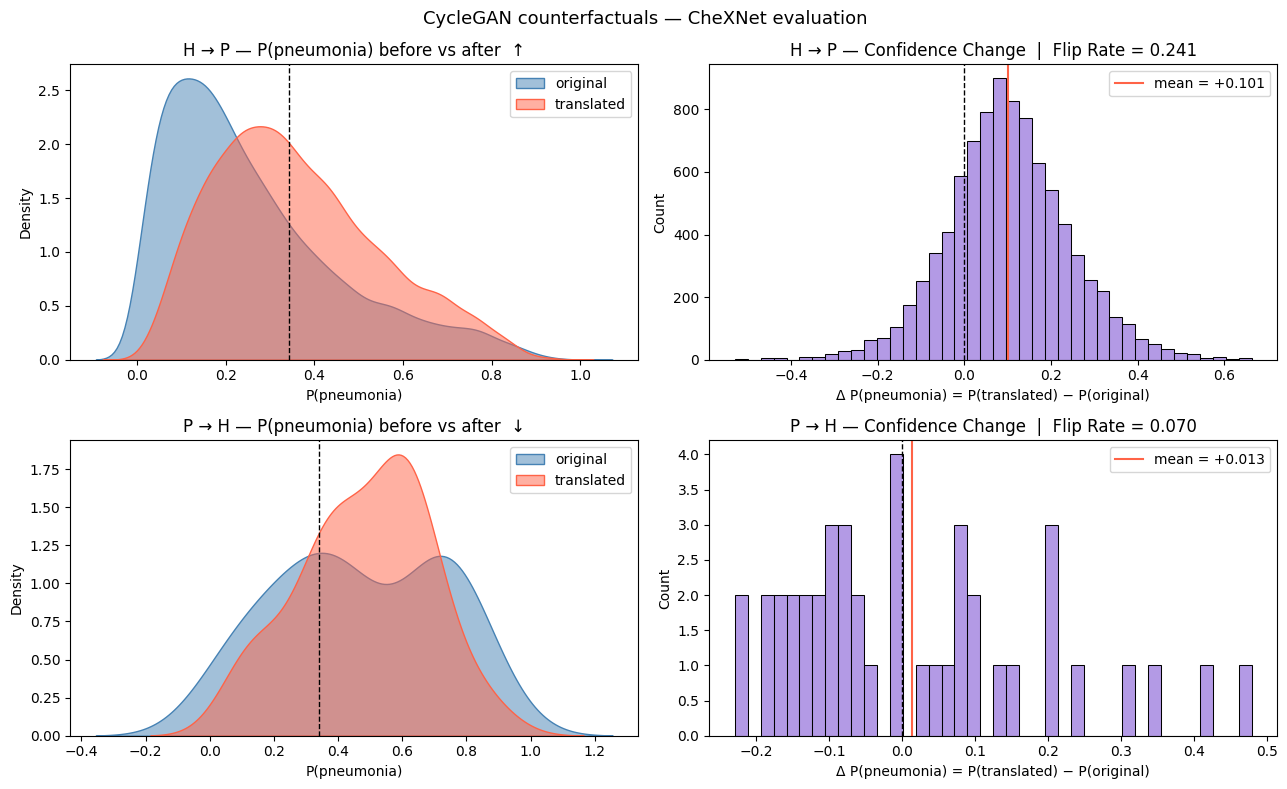

Saved to results/cyclegan_flip_rate.png


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("CycleGAN counterfactuals — CheXNet evaluation", fontsize=13)

for row, (df, direction, expected) in enumerate([
    (h2p_df, "H → P", "↑"),
    (p2h_df, "P → H", "↓"),
]):
    # P(pneumonia) distribution before / after
    ax = axes[row, 0]
    sns.kdeplot(df["p_original"],   ax=ax, fill=True, color="steelblue",
                alpha=0.5, label="original", common_norm=False)
    sns.kdeplot(df["p_translated"], ax=ax, fill=True, color="tomato",
                alpha=0.5, label="translated", common_norm=False)
    ax.axvline(threshold, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("P(pneumonia)")
    ax.set_ylabel("Density")
    ax.set_title(f"{direction} — P(pneumonia) before vs after  {expected}")
    ax.legend()

    # Confidence change distribution
    ax = axes[row, 1]
    sns.histplot(df["delta"], ax=ax, bins=40, color="mediumpurple", alpha=0.7)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(df["delta"].mean(), color="tomato", linestyle="-", linewidth=1.5,
               label=f"mean = {df['delta'].mean():+.3f}")
    ax.set_xlabel("Δ P(pneumonia) = P(translated) − P(original)")
    ax.set_ylabel("Count")
    ax.set_title(f"{direction} — Confidence Change  |  Flip Rate = {df['flip'].mean():.3f}")
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cyclegan_flip_rate.png", dpi=120)
plt.show()
print("Saved to results/cyclegan_flip_rate.png")

## 9. Save results

In [43]:
import json

h2p_df.to_csv(RESULTS_DIR / "cyclegan_h2p_scores.csv", index=False)
p2h_df.to_csv(RESULTS_DIR / "cyclegan_p2h_scores.csv", index=False)

summary = {
    "healthy_to_pneumonia": {
        "n_pairs"   : len(h2p_df),
        "flip_rate" : round(h2p_df["flip"].mean(), 4),
        "delta_mean": round(h2p_df["delta"].mean(), 4),
        "delta_std" : round(h2p_df["delta"].std(),  4),
    },
    "pneumonia_to_healthy": {
        "n_pairs"   : len(p2h_df),
        "flip_rate" : round(p2h_df["flip"].mean(), 4),
        "delta_mean": round(p2h_df["delta"].mean(), 4),
        "delta_std" : round(p2h_df["delta"].std(),  4),
    },
}

with open(RESULTS_DIR / "cyclegan_flip_rate.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "healthy_to_pneumonia": {
    "n_pairs": 8978,
    "flip_rate": 0.241,
    "delta_mean": 0.1007,
    "delta_std": 0.1407
  },
  "pneumonia_to_healthy": {
    "n_pairs": 43,
    "flip_rate": 0.0698,
    "delta_mean": 0.0133,
    "delta_std": 0.1735
  }
}
